# Análisis de Portafolio de Inversiones Colombia

**Autor:** Omar Ortegón  
**Fecha:** Abril 2026  
**Herramientas:** Python · Pandas · NumPy · Matplotlib · yfinance  
**LinkedIn:** [linkedin.com/in/omar-ortegon94](https://www.linkedin.com/in/omar-ortegon94)

---

## Objetivo

Este proyecto analiza el comportamiento histórico y las características de riesgo-rendimiento de un portafolio diversificado que combina **activos colombianos e internacionales**, utilizando técnicas cuantitativas estándar de la industria financiera.

El análisis incluye:

1. **Análisis individual** de cada activo (rendimiento, volatilidad, Sharpe)
2. **Análisis de correlaciones** para evaluar diversificación
3. **Simulación de portafolio** con rendimiento acumulado
4. **Optimización de Markowitz** con frontera eficiente (Monte Carlo)
5. **Análisis de riesgo** con Value at Risk (VaR) y Maximum Drawdown
6. **Comparación de estrategias** de asignación de activos

## ¿Por qué este análisis es relevante?

El mercado colombiano presenta características particulares: exposición a commodities (petróleo), riesgo cambiario (USD/COP), y una correlación con mercados desarrollados que varía según el ciclo económico. Un inversionista colombiano que busca diversificación necesita entender cómo interactúan los activos locales con los internacionales, y este análisis proporciona herramientas cuantitativas para tomar esas decisiones.

---

## 1. Configuración del entorno y descarga de datos

In [1]:
# Instalación de dependencias (solo necesario en Google Colab)
!pip install yfinance -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import yfinance as yf
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración visual consistente
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Paleta de colores del proyecto
COLORES = {
    'ecopetrol': '#1B4F72',
    'bancolombia': '#1E8449',
    'isa': '#8E44AD',
    'nutresa': '#E67E22',
    'sp500': '#2E86C1',
    'bonos': '#95A5A6',
    'oro': '#F1C40F',
    'portafolio': '#E74C3C',
    'benchmark': '#2C3E50'
}

print('✅ Entorno configurado correctamente')
print(f'📅 Fecha de ejecución: {datetime.now().strftime("%d de %B de %Y")}')

✅ Entorno configurado correctamente
📅 Fecha de ejecución: 27 de April de 2026


### 1.1 Definición del universo de activos

El portafolio combina activos de diferentes clases y geografías para evaluar el efecto de la diversificación:

| Activo | Ticker | Clase | Geografía | Justificación |
|--------|--------|-------|-----------|---------------|
| Ecopetrol | EC | Acción | Colombia | Mayor empresa del país, exposición a petróleo |
| Bancolombia | CIB | Acción | Colombia | Mayor banco privado, proxy del sector financiero |
| ISA | ISA.CL | Acción | Colombia/LATAM | Infraestructura energética regional |
| Grupo Nutresa | NGRD | Acción | Colombia | Consumo masivo, menor correlación con commodities |
| ETF S&P 500 | SPY | ETF Índice | EE.UU. | Diversificación internacional, mercado desarrollado |
| ETF Bonos US | BND | ETF Renta Fija | EE.UU. | Cobertura defensiva, baja correlación con renta variable |
| ETF Oro | GLD | ETF Commodity | Global | Activo refugio, cobertura contra inflación |

In [3]:
# Definición del portafolio
ACTIVOS = {
    'Ecopetrol':    {'ticker': 'EC',     'peso': 0.15, 'clase': 'Acción Colombia',   'color': COLORES['ecopetrol']},
    'Bancolombia':  {'ticker': 'CIB',    'peso': 0.15, 'clase': 'Acción Colombia',   'color': COLORES['bancolombia']},
    'ISA':          {'ticker': 'ISA.CL', 'peso': 0.10, 'clase': 'Acción Colombia',   'color': COLORES['isa']},
    'Nutresa':      {'ticker': 'NUTRESA.CL',   'peso': 0.10, 'clase': 'Acción Colombia',   'color': COLORES['nutresa']},
    'S&P 500':      {'ticker': 'SPY',    'peso': 0.25, 'clase': 'ETF Internacional', 'color': COLORES['sp500']},
    'Bonos US':     {'ticker': 'BND',    'peso': 0.10, 'clase': 'ETF Renta Fija',    'color': COLORES['bonos']},
    'Oro':          {'ticker': 'GLD',    'peso': 0.15, 'clase': 'ETF Commodity',      'color': COLORES['oro']},
}

PERIODO = '3y'          # Ventana de análisis
TASA_LIBRE_RIESGO = 0.05  # Aproximación TES corto plazo Colombia
DIAS_BURSATILES = 252

# Validar que los pesos suman 100%
pesos_total = sum(a['peso'] for a in ACTIVOS.values())
assert abs(pesos_total - 1.0) < 0.001, f'Los pesos deben sumar 1.0, suman {pesos_total}'
print(f'✅ Portafolio definido: {len(ACTIVOS)} activos, pesos suman {pesos_total:.0%}')

✅ Portafolio definido: 7 activos, pesos suman 100%


In [4]:
# Descarga de datos históricos
precios = pd.DataFrame()
resumen_descarga = []

for nombre, info in ACTIVOS.items():
    try:
        data = yf.download(info['ticker'], period=PERIODO, progress=False)
        precios[nombre] = data['Close']
        fecha_inicio = data.index[0].strftime('%Y-%m-%d')
        fecha_fin = data.index[-1].strftime('%Y-%m-%d')
        resumen_descarga.append({
            'Activo': nombre,
            'Ticker': info['ticker'],
            'Registros': len(data),
            'Desde': fecha_inicio,
            'Hasta': fecha_fin
        })
        print(f'  ✅ {nombre} ({info["ticker"]}): {len(data)} registros [{fecha_inicio} → {fecha_fin}]')
    except Exception as e:
        print(f'  ❌ {nombre} ({info["ticker"]}): Error - {e}')

# Eliminar días con datos faltantes para asegurar consistencia
precios = precios.dropna()
print(f'\n📊 Dataset final: {len(precios)} días de trading con datos completos para todos los activos')
print(f'📅 Período: {precios.index[0].strftime("%Y-%m-%d")} → {precios.index[-1].strftime("%Y-%m-%d")}')

  ✅ Ecopetrol (EC): 753 registros [2023-04-25 → 2026-04-24]
  ✅ Bancolombia (CIB): 753 registros [2023-04-25 → 2026-04-24]
  ✅ ISA (ISA.CL): 760 registros [2023-04-24 → 2026-04-24]
  ✅ Nutresa (NUTRESA.CL): 761 registros [2023-04-24 → 2026-04-24]
  ✅ S&P 500 (SPY): 753 registros [2023-04-25 → 2026-04-24]
  ✅ Bonos US (BND): 753 registros [2023-04-25 → 2026-04-24]
  ✅ Oro (GLD): 753 registros [2023-04-25 → 2026-04-24]

📊 Dataset final: 730 días de trading con datos completos para todos los activos
📅 Período: 2023-04-25 → 2026-04-24


---

## 2. Análisis individual de activos

Antes de analizar el portafolio como conjunto, es fundamental entender el comportamiento individual de cada activo. Las métricas clave son:

- **Rendimiento anualizado**: crecimiento promedio esperado por año
- **Volatilidad anualizada**: desviación estándar de los rendimientos, principal medida de riesgo
- **Ratio Sharpe**: rendimiento ajustado por riesgo (cuánto rendimiento se obtiene por cada unidad de riesgo asumido)
- **Maximum Drawdown**: máxima caída desde un pico, mide el peor escenario histórico

In [5]:
# Calcular rendimientos diarios logarítmicos
# Se usan rendimientos logarítmicos por su propiedad de aditividad temporal
rendimientos = np.log(precios / precios.shift(1)).dropna()

# Función para calcular Maximum Drawdown
def calcular_max_drawdown(serie_precios):
    """Calcula el Maximum Drawdown: la mayor caída porcentual desde un pico."""
    pico_acumulado = serie_precios.cummax()
    drawdown = (serie_precios - pico_acumulado) / pico_acumulado
    return drawdown.min()

# Calcular métricas para cada activo
metricas = pd.DataFrame(index=rendimientos.columns)
metricas['Rend. Anual'] = rendimientos.mean() * DIAS_BURSATILES
metricas['Volatilidad'] = rendimientos.std() * np.sqrt(DIAS_BURSATILES)
metricas['Sharpe'] = (metricas['Rend. Anual'] - TASA_LIBRE_RIESGO) / metricas['Volatilidad']
metricas['Max Drawdown'] = precios.apply(calcular_max_drawdown)
metricas['Rend. Total'] = (precios.iloc[-1] / precios.iloc[0]) - 1
metricas['Peso'] = [ACTIVOS[n]['peso'] for n in metricas.index]

# Mostrar tabla formateada
print('=' * 90)
print('MÉTRICAS INDIVIDUALES POR ACTIVO (Anualizadas)')
print('=' * 90)
print(f'{"":<14} {"Rend.Anual":>10} {"Volatilidad":>11} {"Sharpe":>8} {"MaxDD":>9} {"Rend.Total":>11} {"Peso":>6}')
print('─' * 90)

for nombre, row in metricas.iterrows():
    indicador = '🟢' if row['Sharpe'] > 0.5 else ('🟡' if row['Sharpe'] > 0 else '🔴')
    print(f'{indicador} {nombre:<12} {row["Rend. Anual"]:>+9.2%} {row["Volatilidad"]:>10.2%} '
          f'{row["Sharpe"]:>7.2f} {row["Max Drawdown"]:>8.1%} {row["Rend. Total"]:>+10.2%} {row["Peso"]:>5.0%}')

MÉTRICAS INDIVIDUALES POR ACTIVO (Anualizadas)
               Rend.Anual Volatilidad   Sharpe     MaxDD  Rend.Total   Peso
──────────────────────────────────────────────────────────────────────────────────────────
🟢 Ecopetrol      +24.41%     33.63%    0.58   -38.0%   +102.63%   15%
🟢 Bancolombia    +49.34%     30.88%    1.44   -23.0%   +316.78%   15%
🟢 ISA            +26.32%     37.25%    0.57   -26.2%   +114.15%   10%
🟢 Nutresa        +63.16%     53.32%    1.09   -41.8%   +521.59%   10%
🟢 S&P 500        +20.83%     15.40%    1.03   -18.8%    +82.70%   25%
🔴 Bonos US        +3.59%      5.56%   -0.25    -7.0%    +10.95%   10%
🟢 Oro            +29.28%     20.13%    1.21   -19.2%   +133.24%   15%


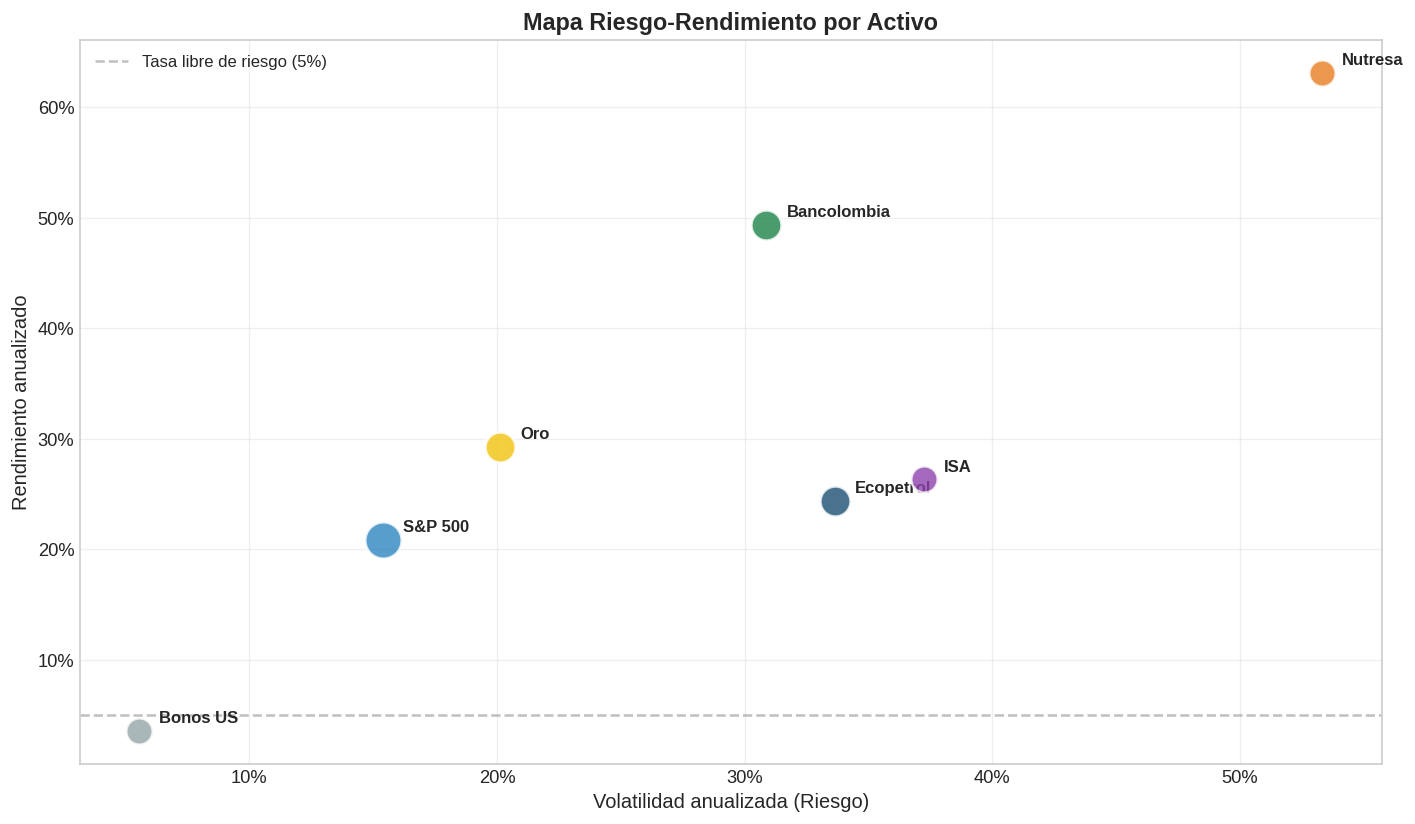

📌 El tamaño de cada burbuja refleja su peso en el portafolio.
   Activos arriba y a la izquierda son más eficientes (más rendimiento por unidad de riesgo).


In [6]:
# Visualización: Rendimiento vs Riesgo (Risk-Return Scatter)
fig, ax = plt.subplots(figsize=(12, 7))

for nombre, row in metricas.iterrows():
    color = ACTIVOS[nombre]['color']
    tamaño = row['Peso'] * 1500 + 100  # Tamaño proporcional al peso
    ax.scatter(row['Volatilidad'], row['Rend. Anual'],
              s=tamaño, c=color, alpha=0.8, edgecolors='white', linewidths=1.5, zorder=5)
    ax.annotate(nombre, (row['Volatilidad'], row['Rend. Anual']),
               textcoords='offset points', xytext=(12, 5), fontsize=10, fontweight='bold')

# Línea de tasa libre de riesgo
ax.axhline(y=TASA_LIBRE_RIESGO, color='gray', linestyle='--', alpha=0.5, label=f'Tasa libre de riesgo ({TASA_LIBRE_RIESGO:.0%})')

ax.set_xlabel('Volatilidad anualizada (Riesgo)', fontsize=12)
ax.set_ylabel('Rendimiento anualizado', fontsize=12)
ax.set_title('Mapa Riesgo-Rendimiento por Activo')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('img/01_riesgo_rendimiento.png', bbox_inches='tight')
plt.show()

print('📌 El tamaño de cada burbuja refleja su peso en el portafolio.')
print('   Activos arriba y a la izquierda son más eficientes (más rendimiento por unidad de riesgo).')

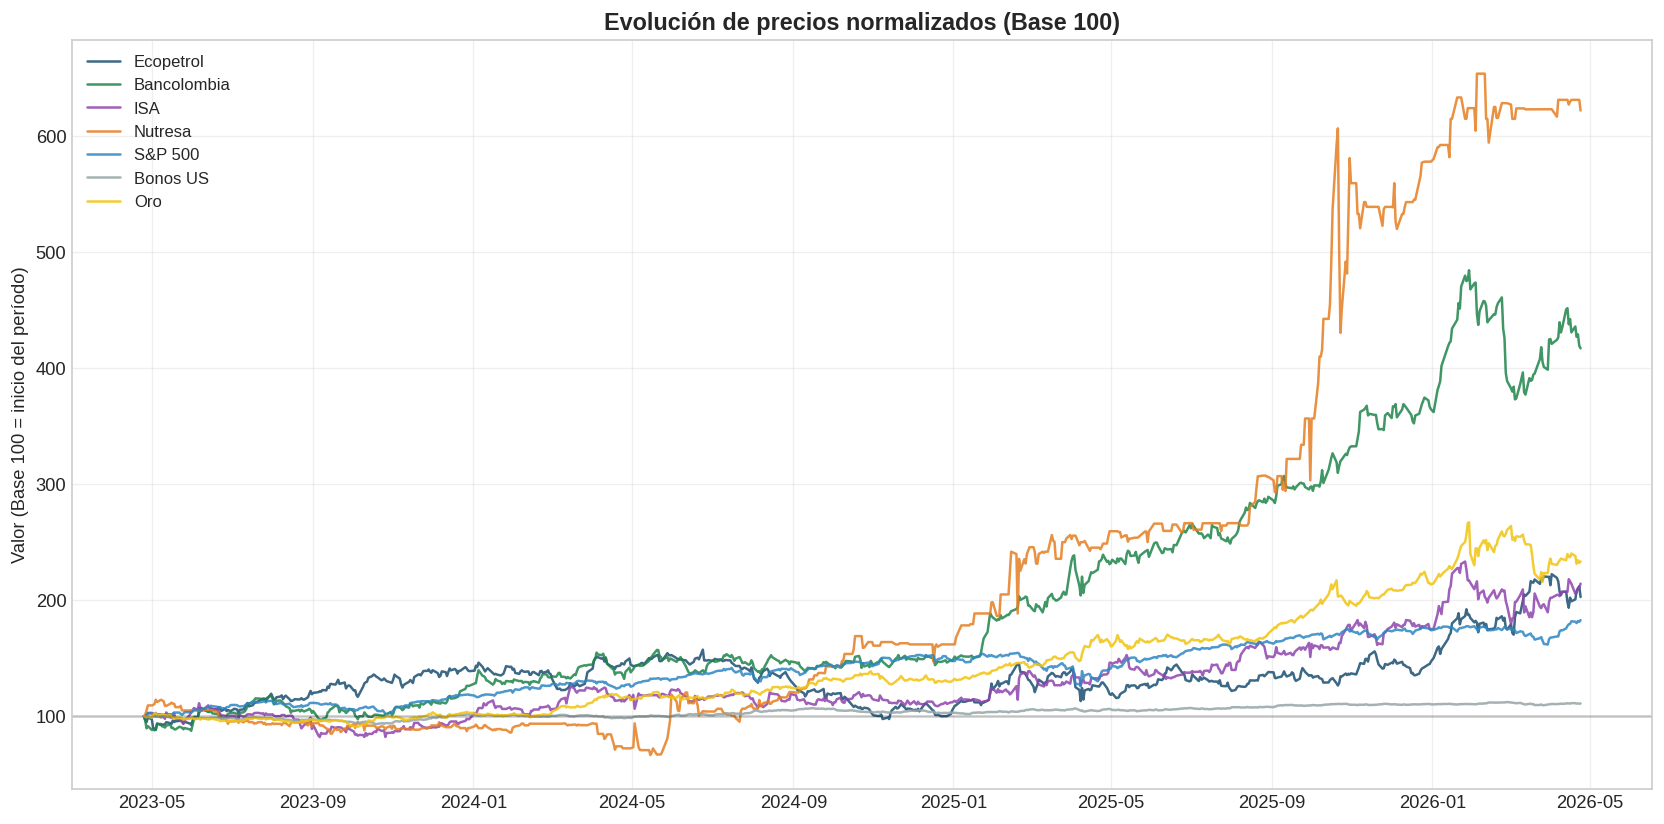

In [7]:
# Evolución de precios normalizados (base 100)
precios_norm = (precios / precios.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 7))

for nombre in precios_norm.columns:
    color = ACTIVOS[nombre]['color']
    ax.plot(precios_norm[nombre], label=nombre, color=color, linewidth=1.5, alpha=0.85)

ax.axhline(y=100, color='black', linestyle='-', alpha=0.2)
ax.set_title('Evolución de precios normalizados (Base 100)')
ax.set_ylabel('Valor (Base 100 = inicio del período)')
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('img/02_precios_normalizados.png', bbox_inches='tight')
plt.show()


---

## 3. Análisis de correlaciones

La correlación entre activos es el factor más importante para la diversificación. Dos activos con **correlación baja o negativa** reducen el riesgo total del portafolio sin sacrificar proporcionalmente el rendimiento. Este es el principio fundamental de la teoría moderna de portafolios.

- **Correlación = 1.0**: los activos se mueven exactamente igual (sin diversificación)
- **Correlación = 0.0**: los activos se mueven de forma independiente (diversificación moderada)
- **Correlación = -1.0**: los activos se mueven en dirección opuesta (máxima diversificación)

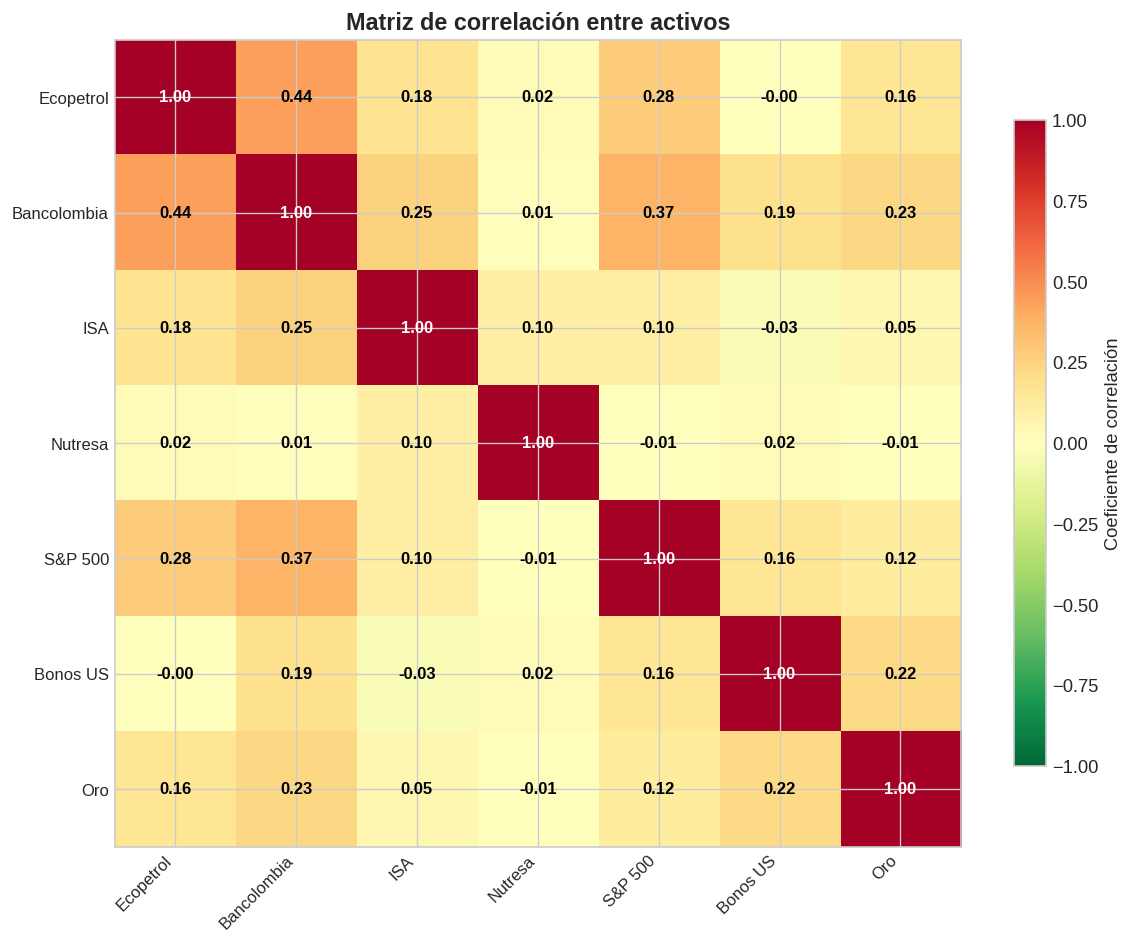

In [8]:
# Matriz de correlación
corr = rendimientos.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='RdYlGn_r', vmin=-1, vmax=1, aspect='auto')

# Etiquetas
n = len(corr)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(corr.index, fontsize=10)

# Valores en cada celda
for i in range(n):
    for j in range(n):
        color_texto = 'white' if abs(corr.values[i, j]) > 0.5 else 'black'
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                color=color_texto, fontsize=10, fontweight='bold')

ax.set_title('Matriz de correlación entre activos')
plt.colorbar(im, label='Coeficiente de correlación', shrink=0.8)
plt.tight_layout()
plt.savefig('img/03_correlacion.png', bbox_inches='tight')
plt.show()


In [9]:
# Identificar los pares más y menos correlacionados
pares = []
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        pares.append({
            'Activo 1': corr.index[i],
            'Activo 2': corr.columns[j],
            'Correlación': corr.values[i, j]
        })

pares_df = pd.DataFrame(pares).sort_values('Correlación')

print('PARES CON MENOR CORRELACIÓN (mejor diversificación)')
print('─' * 55)
for _, p in pares_df.head(5).iterrows():
    print(f'  🟢 {p["Activo 1"]:>12} ↔ {p["Activo 2"]:<12}  {p["Correlación"]:>+.3f}')

print(f'\nPARES CON MAYOR CORRELACIÓN (menor diversificación)')
print('─' * 55)
for _, p in pares_df.tail(5).iterrows():
    print(f'  🔴 {p["Activo 1"]:>12} ↔ {p["Activo 2"]:<12}  {p["Correlación"]:>+.3f}')

PARES CON MENOR CORRELACIÓN (mejor diversificación)
───────────────────────────────────────────────────────
  🟢          ISA ↔ Bonos US      -0.027
  🟢      Nutresa ↔ Oro           -0.006
  🟢      Nutresa ↔ S&P 500       -0.005
  🟢    Ecopetrol ↔ Bonos US      -0.003
  🟢  Bancolombia ↔ Nutresa       +0.008

PARES CON MAYOR CORRELACIÓN (menor diversificación)
───────────────────────────────────────────────────────
  🔴  Bancolombia ↔ Oro           +0.234
  🔴  Bancolombia ↔ ISA           +0.252
  🔴    Ecopetrol ↔ S&P 500       +0.276
  🔴  Bancolombia ↔ S&P 500       +0.371
  🔴    Ecopetrol ↔ Bancolombia   +0.441


---

## 4. Rendimiento del portafolio combinado

Ahora evaluamos cómo se habría comportado el portafolio completo con los pesos definidos. La pregunta central es: **¿la diversificación generó valor?** Es decir, ¿el portafolio combinado ofreció un mejor perfil de riesgo-rendimiento que los activos individuales?

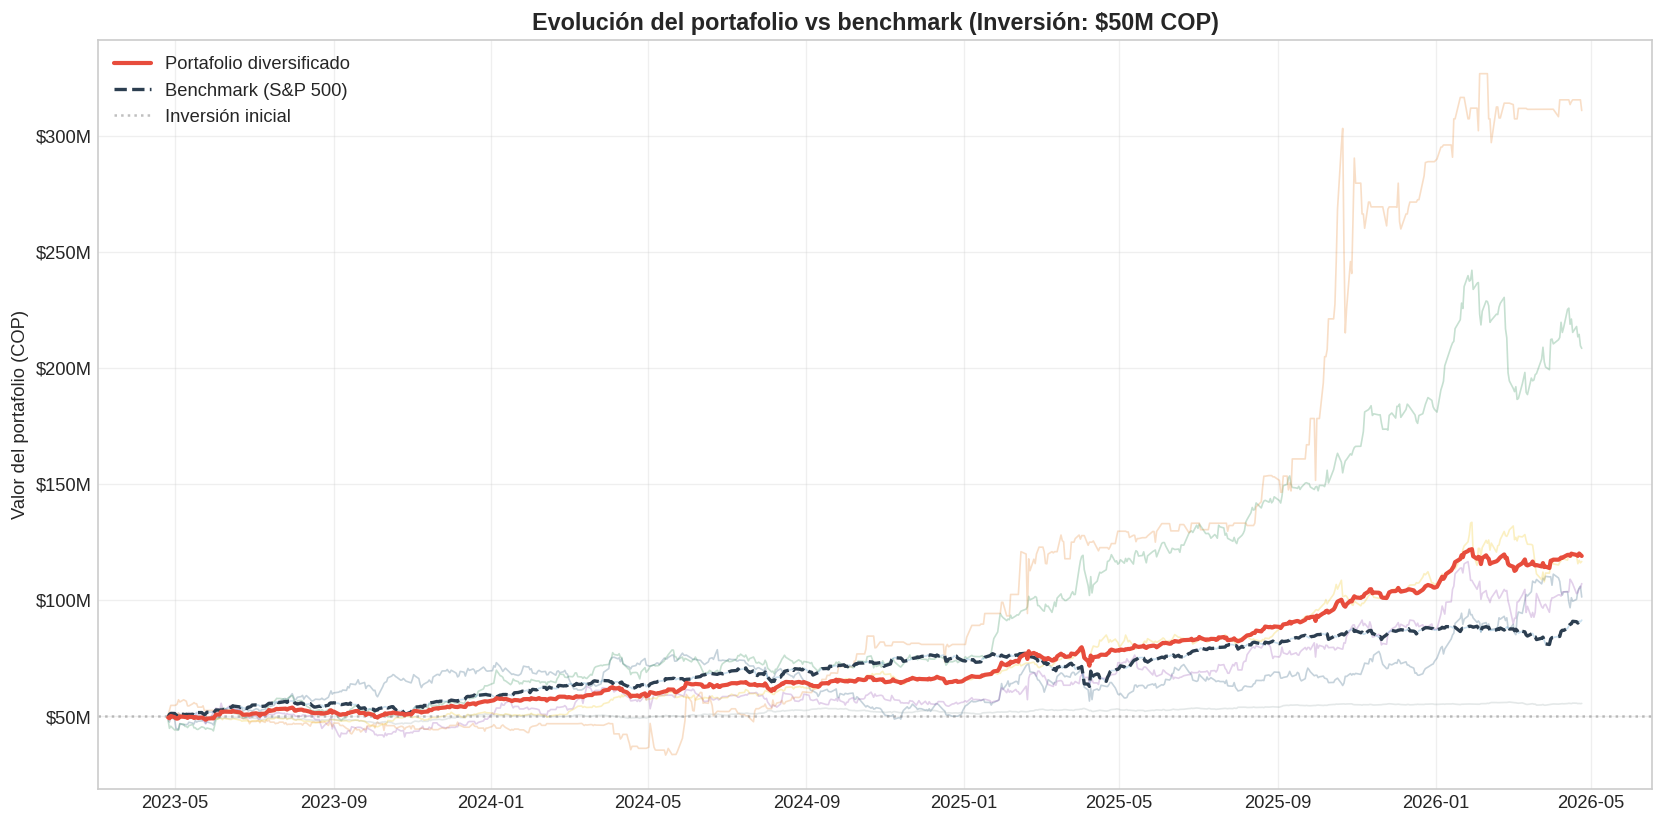


═══════════════════════════════════════════════════════
  RESULTADO DE INVERSIÓN
═══════════════════════════════════════════════════════
  Inversión inicial:     $    50,000,000
  Valor final portafolio:$   118,988,229 (+138.0%)
  Valor final benchmark: $    91,349,672 (+82.7%)
───────────────────────────────────────────────────────
  Rendimiento anualizado:      +29.97%
  Volatilidad anualizada:       14.11%
  Ratio Sharpe:                   1.77


In [10]:
# Calcular rendimiento del portafolio ponderado
pesos_array = np.array([ACTIVOS[nombre]['peso'] for nombre in rendimientos.columns])
rendimiento_portafolio = (rendimientos * pesos_array).sum(axis=1)

# Métricas del portafolio
rend_port = rendimiento_portafolio.mean() * DIAS_BURSATILES
vol_port = rendimiento_portafolio.std() * np.sqrt(DIAS_BURSATILES)
sharpe_port = (rend_port - TASA_LIBRE_RIESGO) / vol_port

# Calcular valor acumulado con inversión hipotética
INVERSION_INICIAL = 50_000_000  # $50M COP

valor_portafolio = INVERSION_INICIAL * np.exp(rendimiento_portafolio.cumsum())

# Benchmark: S&P 500 como referencia
valor_benchmark = INVERSION_INICIAL * np.exp(rendimientos['S&P 500'].cumsum())

# Gráfica
fig, ax = plt.subplots(figsize=(14, 7))

# Activos individuales (fondo, opacidad baja)
for nombre in rendimientos.columns:
    valor_individual = INVERSION_INICIAL * np.exp(rendimientos[nombre].cumsum())
    ax.plot(valor_individual, alpha=0.25, linewidth=1, color=ACTIVOS[nombre]['color'])

# Portafolio y benchmark (líneas principales)
ax.plot(valor_portafolio, color=COLORES['portafolio'], linewidth=2.5, label='Portafolio diversificado', zorder=10)
ax.plot(valor_benchmark, color=COLORES['benchmark'], linewidth=2, linestyle='--', label='Benchmark (S&P 500)', zorder=9)
ax.axhline(y=INVERSION_INICIAL, color='gray', linestyle=':', alpha=0.5, label='Inversión inicial')

# Formato
ax.set_title(f'Evolución del portafolio vs benchmark (Inversión: ${INVERSION_INICIAL/1e6:.0f}M COP)')
ax.set_ylabel('Valor del portafolio (COP)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.legend(fontsize=11, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('img/04_rendimiento_portafolio.png', bbox_inches='tight')
plt.show()

# Resumen numérico
valor_final = valor_portafolio.iloc[-1]
ganancia = valor_final - INVERSION_INICIAL
valor_benchmark_final = valor_benchmark.iloc[-1]

print(f'\n{"═" * 55}')
print(f'  RESULTADO DE INVERSIÓN')
print(f'{"═" * 55}')
print(f'  Inversión inicial:     ${INVERSION_INICIAL:>14,.0f}')
print(f'  Valor final portafolio:${valor_final:>14,.0f} ({ganancia/INVERSION_INICIAL:>+.1%})')
print(f'  Valor final benchmark: ${valor_benchmark_final:>14,.0f} ({(valor_benchmark_final/INVERSION_INICIAL - 1):>+.1%})')
print(f'{"─" * 55}')
print(f'  Rendimiento anualizado:{rend_port:>+13.2%}')
print(f'  Volatilidad anualizada:{vol_port:>13.2%}')
print(f'  Ratio Sharpe:          {sharpe_port:>13.2f}')

In [11]:
# Beneficio de la diversificación: comparar volatilidad del portafolio vs promedio
vol_promedio_ponderado = (metricas['Volatilidad'] * metricas['Peso']).sum()
reduccion_riesgo = 1 - vol_port / vol_promedio_ponderado

print(f'EFECTO DE LA DIVERSIFICACIÓN')
print(f'─' * 55)
print(f'  Volatilidad promedio ponderada: {vol_promedio_ponderado:.2%}')
print(f'  Volatilidad real del portafolio:{vol_port:.2%}')
print(f'  Reducción de riesgo:            {reduccion_riesgo:.1%}')
print(f'\n  📌 La diversificación redujo el riesgo un {reduccion_riesgo:.1%}')
print(f'     respecto a mantener los activos de forma independiente.')
print(f'     Este es el beneficio cuantificable de combinar activos')
print(f'     con correlaciones imperfectas.')

EFECTO DE LA DIVERSIFICACIÓN
───────────────────────────────────────────────────────
  Volatilidad promedio ponderada: 26.16%
  Volatilidad real del portafolio:14.11%
  Reducción de riesgo:            46.1%

  📌 La diversificación redujo el riesgo un 46.1%
     respecto a mantener los activos de forma independiente.
     Este es el beneficio cuantificable de combinar activos
     con correlaciones imperfectas.


---

## 5. Optimización de portafolio: Frontera eficiente de Markowitz

La **frontera eficiente** representa el conjunto de portafolios que ofrecen el **máximo rendimiento posible para cada nivel de riesgo** (o equivalentemente, el mínimo riesgo para cada nivel de rendimiento).

Cualquier portafolio que no esté sobre la frontera eficiente es subóptimo: existe una combinación de pesos que daría mejor rendimiento al mismo riesgo, o el mismo rendimiento con menor riesgo.

Para construirla, simulamos 10,000 portafolios con pesos aleatorios y evaluamos sus características.

In [12]:
# Simulación Monte Carlo para la frontera eficiente
N_SIMULACIONES = 10_000
n_activos = len(rendimientos.columns)

# Matrices de rendimientos medios y covarianza (anualizadas)
rend_medios = rendimientos.mean().values * DIAS_BURSATILES
cov_matrix = rendimientos.cov().values * DIAS_BURSATILES

# Almacenar resultados
np.random.seed(42)  # Reproducibilidad
resultados_sim = np.zeros((N_SIMULACIONES, 3))  # rendimiento, volatilidad, sharpe
pesos_sim = np.zeros((N_SIMULACIONES, n_activos))

for i in range(N_SIMULACIONES):
    # Generar pesos aleatorios normalizados
    w = np.random.random(n_activos)
    w = w / w.sum()
    pesos_sim[i] = w

    # Rendimiento esperado del portafolio
    rend_p = np.dot(w, rend_medios)

    # Volatilidad del portafolio (usando la matriz de covarianza)
    vol_p = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))

    # Sharpe
    sharpe_p = (rend_p - TASA_LIBRE_RIESGO) / vol_p

    resultados_sim[i] = [rend_p, vol_p, sharpe_p]

# Convertir a DataFrame
sim_df = pd.DataFrame(resultados_sim, columns=['Rendimiento', 'Volatilidad', 'Sharpe'])

# Identificar portafolios óptimos
idx_max_sharpe = sim_df['Sharpe'].idxmax()
idx_min_vol = sim_df['Volatilidad'].idxmin()

opt_sharpe = sim_df.iloc[idx_max_sharpe]
opt_minvol = sim_df.iloc[idx_min_vol]
pesos_opt_sharpe = pesos_sim[idx_max_sharpe]
pesos_opt_minvol = pesos_sim[idx_min_vol]

print(f'✅ {N_SIMULACIONES:,} portafolios simulados')
print(f'\n⭐ Portafolio Máximo Sharpe:  Rend={opt_sharpe["Rendimiento"]:+.2%} | Vol={opt_sharpe["Volatilidad"]:.2%} | Sharpe={opt_sharpe["Sharpe"]:.2f}')
print(f'🛡️  Portafolio Mínima Varianza: Rend={opt_minvol["Rendimiento"]:+.2%} | Vol={opt_minvol["Volatilidad"]:.2%} | Sharpe={opt_minvol["Sharpe"]:.2f}')

✅ 10,000 portafolios simulados

⭐ Portafolio Máximo Sharpe:  Rend=+34.14% | Vol=14.19% | Sharpe=2.05
🛡️  Portafolio Mínima Varianza: Rend=+16.94% | Vol=8.09% | Sharpe=1.47


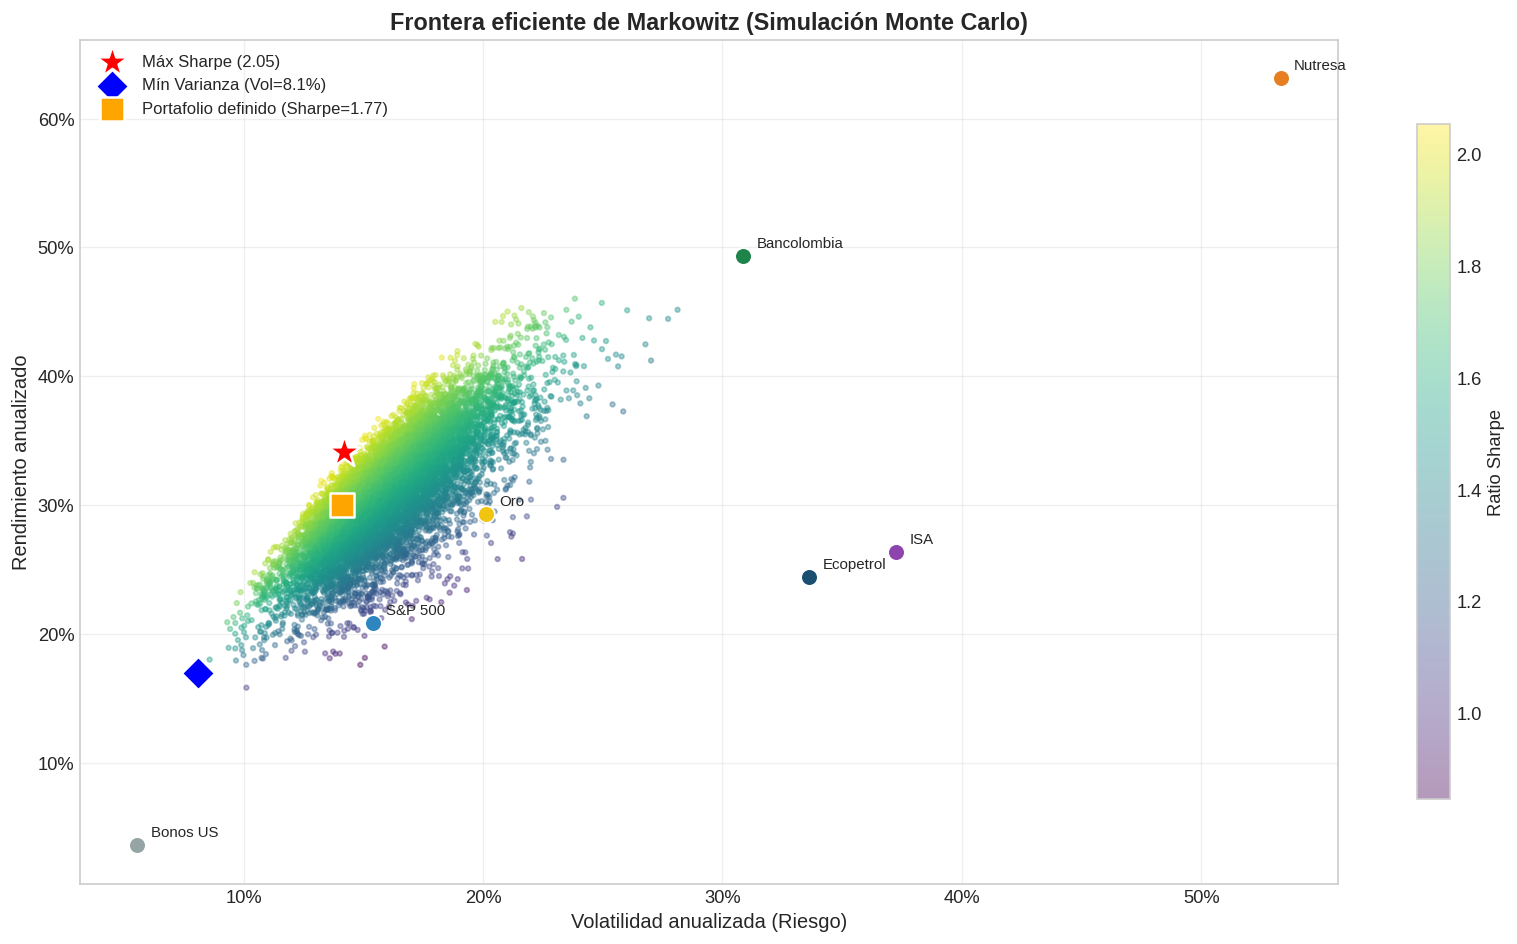

In [13]:
# Gráfica de la frontera eficiente
fig, ax = plt.subplots(figsize=(14, 8))

# Nube de portafolios simulados
scatter = ax.scatter(sim_df['Volatilidad'], sim_df['Rendimiento'],
                     c=sim_df['Sharpe'], cmap='viridis', alpha=0.4, s=8)
plt.colorbar(scatter, label='Ratio Sharpe', shrink=0.8)

# Portafolio óptimo (máximo Sharpe)
ax.scatter(opt_sharpe['Volatilidad'], opt_sharpe['Rendimiento'],
           color='red', marker='*', s=400, zorder=10, edgecolors='white', linewidths=1.5,
           label=f'Máx Sharpe ({opt_sharpe["Sharpe"]:.2f})')

# Portafolio de mínima varianza
ax.scatter(opt_minvol['Volatilidad'], opt_minvol['Rendimiento'],
           color='blue', marker='D', s=200, zorder=10, edgecolors='white', linewidths=1.5,
           label=f'Mín Varianza (Vol={opt_minvol["Volatilidad"]:.1%})')

# Portafolio actual definido
ax.scatter(vol_port, rend_port,
           color='orange', marker='s', s=200, zorder=10, edgecolors='white', linewidths=1.5,
           label=f'Portafolio definido (Sharpe={sharpe_port:.2f})')

# Activos individuales
for i, nombre in enumerate(rendimientos.columns):
    ax.scatter(metricas.loc[nombre, 'Volatilidad'], metricas.loc[nombre, 'Rend. Anual'],
              color=ACTIVOS[nombre]['color'], marker='o', s=100, zorder=8,
              edgecolors='white', linewidths=1)
    ax.annotate(nombre, (metricas.loc[nombre, 'Volatilidad'], metricas.loc[nombre, 'Rend. Anual']),
               textcoords='offset points', xytext=(8, 5), fontsize=9)

ax.set_xlabel('Volatilidad anualizada (Riesgo)', fontsize=12)
ax.set_ylabel('Rendimiento anualizado', fontsize=12)
ax.set_title('Frontera eficiente de Markowitz (Simulación Monte Carlo)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('img/05_frontera_eficiente.png', bbox_inches='tight')
plt.show()


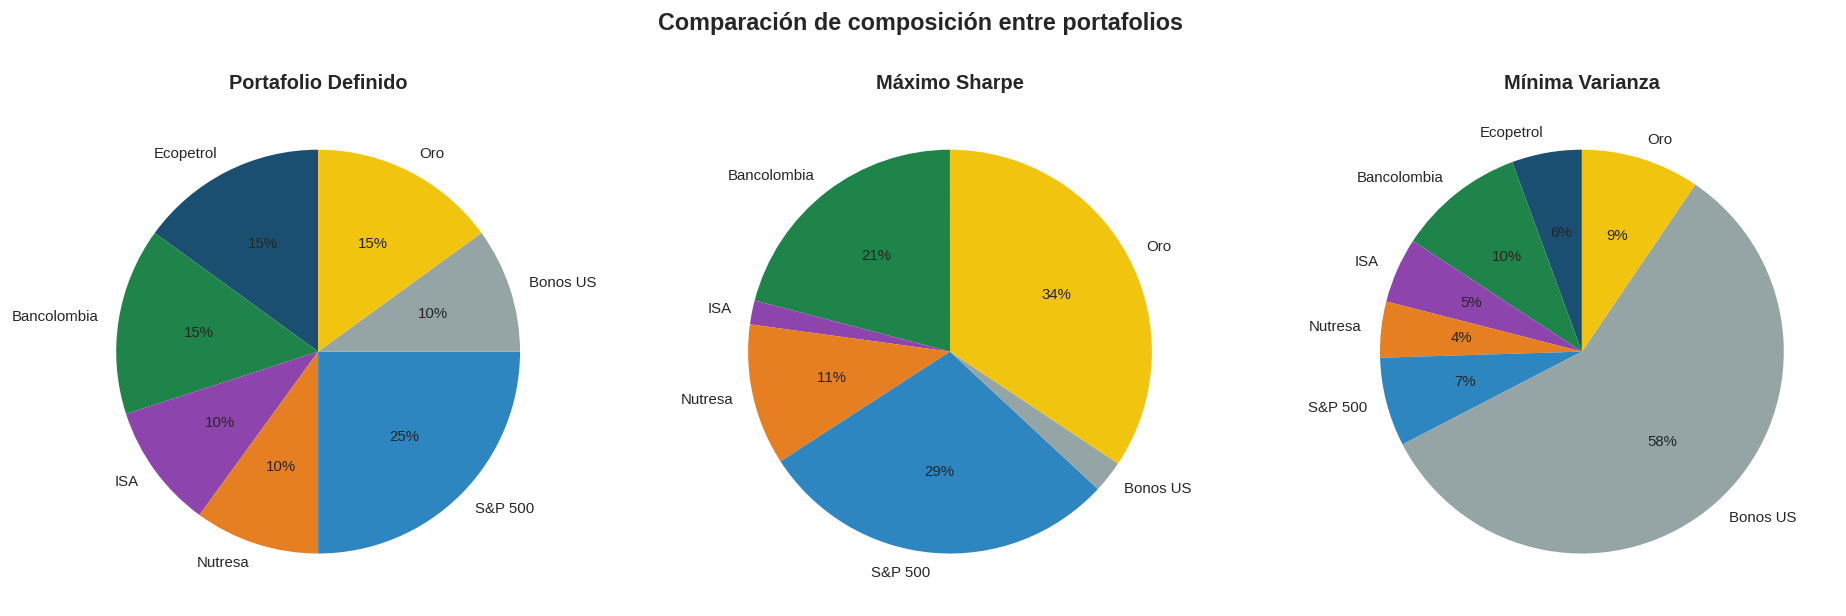


═════════════════════════════════════════════════════════════════
  COMPOSICIÓN COMPARATIVA DE PORTAFOLIOS
═════════════════════════════════════════════════════════════════
Activo           Definido   Máx Sharpe  Mín Varianza
─────────────────────────────────────────────────────────────────
  Ecopetrol        15.0%        0.0%         5.6%
  Bancolombia      15.0%       20.9%        10.2%
  ISA              10.0%        1.9%         5.2%
  Nutresa          10.0%       11.3%         4.5%
  S&P 500          25.0%       28.9%         7.1%
  Bonos US         10.0%        2.6%        57.9%
  Oro              15.0%       34.4%         9.5%
─────────────────────────────────────────────────────────────────
  Rendimiento    +29.97%     +34.14%      +16.94%
  Volatilidad     14.11%      14.19%        8.09%
  Sharpe            1.77        2.05         1.47


In [14]:
# Composición de los portafolios óptimos
nombres_activos = list(rendimientos.columns)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores_pie = [ACTIVOS[n]['color'] for n in nombres_activos]

configs = [
    ('Portafolio Definido', pesos_array),
    ('Máximo Sharpe', pesos_opt_sharpe),
    ('Mínima Varianza', pesos_opt_minvol)
]

for ax, (titulo, pesos_plot) in zip(axes, configs):
    # Filtrar activos con peso > 1% para legibilidad
    mask = pesos_plot > 0.01
    labels = [n if m else '' for n, m in zip(nombres_activos, mask)]
    ax.pie(pesos_plot, labels=labels, autopct=lambda p: f'{p:.0f}%' if p > 3 else '',
           colors=colores_pie, startangle=90, textprops={'fontsize': 9})
    ax.set_title(titulo, fontsize=12, fontweight='bold')

plt.suptitle('Comparación de composición entre portafolios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('img/06_composicion_portafolios.png', bbox_inches='tight')
plt.show()

# Tabla comparativa
print(f'\n{"═" * 65}')
print(f'  COMPOSICIÓN COMPARATIVA DE PORTAFOLIOS')
print(f'{"═" * 65}')
print(f'{"Activo":<14} {"Definido":>10} {"Máx Sharpe":>12} {"Mín Varianza":>13}')
print(f'{"─" * 65}')
for i, nombre in enumerate(nombres_activos):
    print(f'  {nombre:<12} {pesos_array[i]:>9.1%} {pesos_opt_sharpe[i]:>11.1%} {pesos_opt_minvol[i]:>12.1%}')
print(f'{"─" * 65}')
print(f'  {"Rendimiento":<12} {rend_port:>+9.2%} {opt_sharpe["Rendimiento"]:>+11.2%} {opt_minvol["Rendimiento"]:>+12.2%}')
print(f'  {"Volatilidad":<12} {vol_port:>9.2%} {opt_sharpe["Volatilidad"]:>11.2%} {opt_minvol["Volatilidad"]:>12.2%}')
print(f'  {"Sharpe":<12} {sharpe_port:>9.2f} {opt_sharpe["Sharpe"]:>11.2f} {opt_minvol["Sharpe"]:>12.2f}')

---

## 6. Análisis de riesgo

El rendimiento solo cuenta la mitad de la historia. Para un inversionista, es igualmente importante entender **cuánto puede perder** en escenarios adversos. Analizamos dos métricas fundamentales de riesgo:

- **Value at Risk (VaR)**: estima la pérdida máxima esperada en un día con un nivel de confianza dado
- **Maximum Drawdown**: mide la mayor caída acumulada desde un pico, es decir, el peor momento histórico para un inversionista que hubiera comprado en el punto más alto

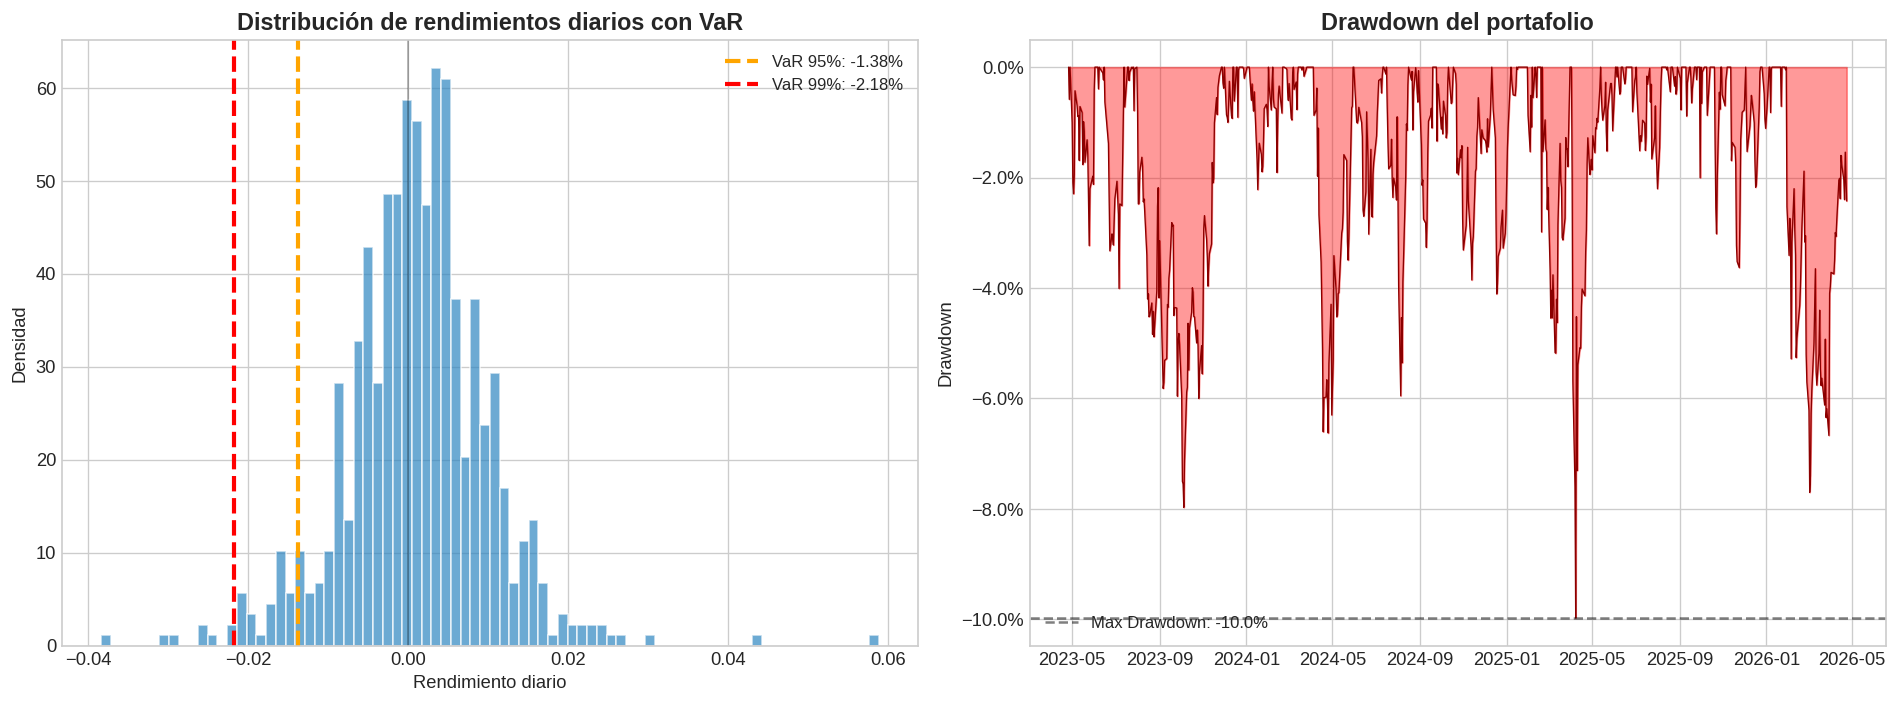


════════════════════════════════════════════════════════════
  ANÁLISIS DE RIESGO DEL PORTAFOLIO
════════════════════════════════════════════════════════════

  Con una inversión de $50,000,000:

  Métrica                          % Diario      $ Impacto
  ──────────────────────────────────────────────────────
  VaR 95% (1 día)                   -1.38% $     -689,750
  VaR 99% (1 día)                   -2.18% $   -1,090,004
  CVaR 95% (Expected Shortfall)     -1.93% $     -962,885
  Maximum Drawdown                  -10.0% $   -4,987,580

  📅 Fecha del Maximum Drawdown: 2025-04-08


In [15]:
# Value at Risk (VaR) - Método histórico
var_95 = np.percentile(rendimiento_portafolio, 5)
var_99 = np.percentile(rendimiento_portafolio, 1)

# Conditional VaR (Expected Shortfall)
cvar_95 = rendimiento_portafolio[rendimiento_portafolio <= var_95].mean()
cvar_99 = rendimiento_portafolio[rendimiento_portafolio <= var_99].mean()

# Maximum Drawdown del portafolio
valor_acum = np.exp(rendimiento_portafolio.cumsum())
pico = valor_acum.cummax()
drawdown = (valor_acum - pico) / pico
max_dd = drawdown.min()
fecha_max_dd = drawdown.idxmin()

# Gráfica de distribución con VaR
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Distribución de rendimientos con VaR
axes[0].hist(rendimiento_portafolio, bins=80, alpha=0.7, color=COLORES['sp500'],
             edgecolor='white', density=True)
axes[0].axvline(x=var_95, color='orange', linewidth=2.5, linestyle='--',
                label=f'VaR 95%: {var_95:.2%}')
axes[0].axvline(x=var_99, color='red', linewidth=2.5, linestyle='--',
                label=f'VaR 99%: {var_99:.2%}')
axes[0].axvline(x=0, color='black', linewidth=1, alpha=0.3)
axes[0].set_title('Distribución de rendimientos diarios con VaR')
axes[0].set_xlabel('Rendimiento diario')
axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=10)

# Panel 2: Drawdown a lo largo del tiempo
axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.4, color='red')
axes[1].plot(drawdown, color='darkred', linewidth=0.8)
axes[1].axhline(y=max_dd, color='black', linestyle='--', alpha=0.5,
                label=f'Max Drawdown: {max_dd:.1%}')
axes[1].set_title('Drawdown del portafolio')
axes[1].set_ylabel('Drawdown')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('img/07_analisis_riesgo.png', bbox_inches='tight')
plt.show()

# Tabla de riesgo
print(f'\n{"═" * 60}')
print(f'  ANÁLISIS DE RIESGO DEL PORTAFOLIO')
print(f'{"═" * 60}')
print(f'\n  Con una inversión de ${INVERSION_INICIAL:,.0f}:')
print(f'\n  {"Métrica":<30} {"% Diario":>10} {"$ Impacto":>14}')
print(f'  {"─" * 54}')
print(f'  {"VaR 95% (1 día)":<30} {var_95:>+9.2%} ${INVERSION_INICIAL * var_95:>+13,.0f}')
print(f'  {"VaR 99% (1 día)":<30} {var_99:>+9.2%} ${INVERSION_INICIAL * var_99:>+13,.0f}')
print(f'  {"CVaR 95% (Expected Shortfall)":<30} {cvar_95:>+9.2%} ${INVERSION_INICIAL * cvar_95:>+13,.0f}')
print(f'  {"Maximum Drawdown":<30} {max_dd:>+9.1%} ${INVERSION_INICIAL * max_dd:>+13,.0f}')
print(f'\n  📅 Fecha del Maximum Drawdown: {fecha_max_dd.strftime("%Y-%m-%d")}')

---

## 7. Comparación de estrategias de asignación

¿Habría sido mejor distribuir el dinero de forma equitativa entre todos los activos? ¿O concentrarse solo en los de mejor Sharpe? Comparamos cuatro estrategias comunes para evaluar si la asignación elegida agrega valor.

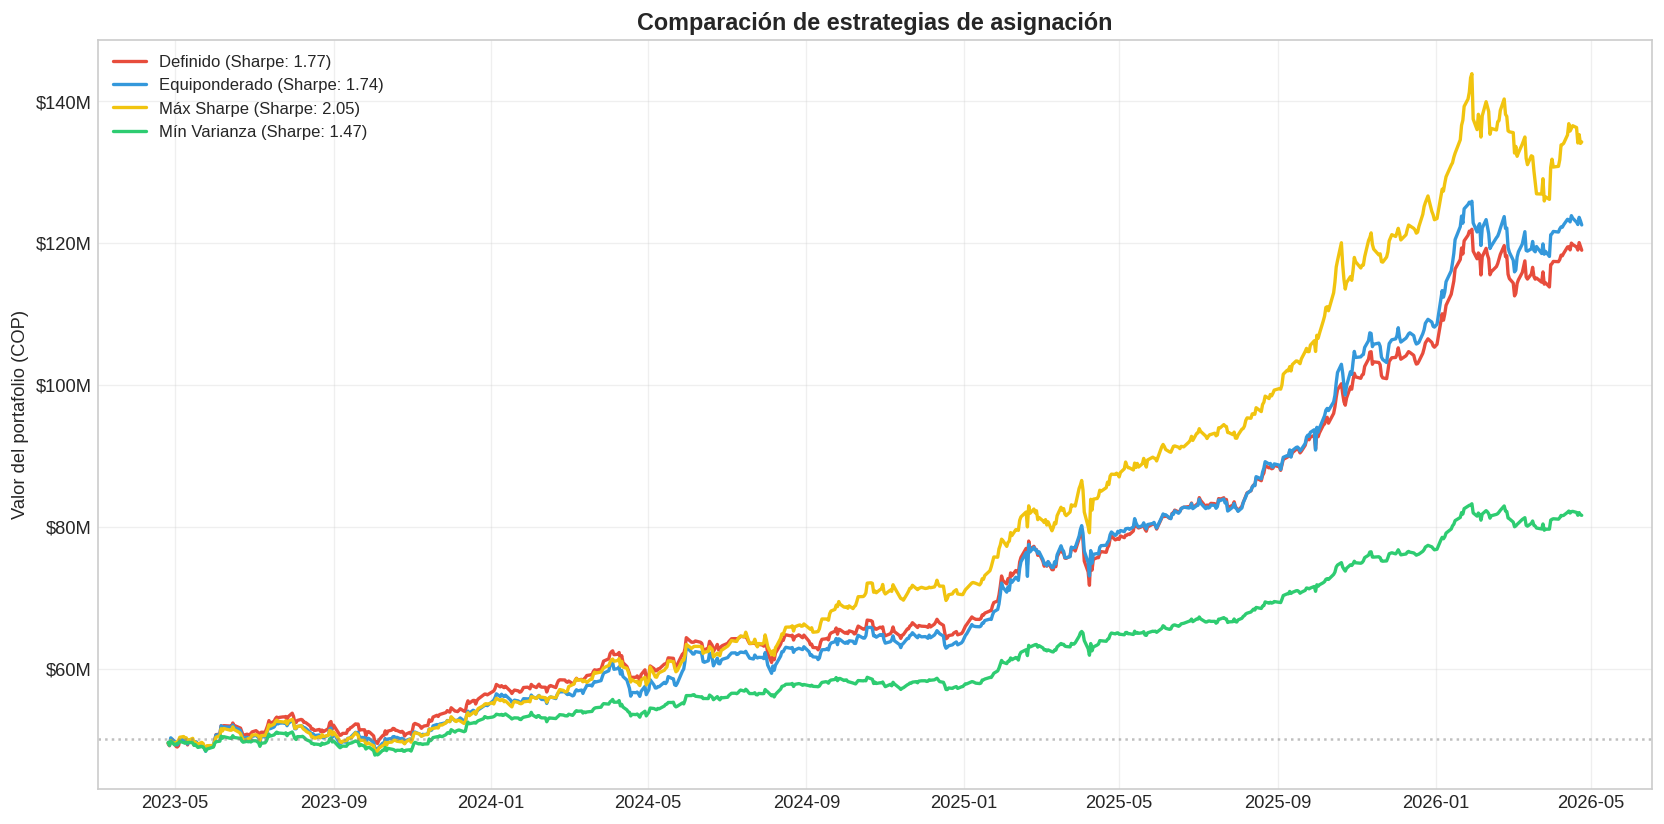


═════════════════════════════════════════════════════════════════════════════════════
  COMPARACIÓN DE ESTRATEGIAS DE ASIGNACIÓN
═════════════════════════════════════════════════════════════════════════════════════
Estrategia       Rend.Anual Volatilidad   Sharpe    Max DD    Valor Final
─────────────────────────────────────────────────────────────────────────────────────
  Definido         +29.97%     14.11%    1.77   -10.0% $ 118,988,229
  Equiponderado    +30.99%     14.94%    1.74    -8.9% $ 122,554,833
⭐Máx Sharpe       +34.14%     14.19%    2.05   -12.5% $ 134,260,593
  Mín Varianza     +16.94%      8.09%    1.47    -6.4% $  81,608,250


In [16]:
# Definir estrategias de asignación
estrategias = {
    'Definido': pesos_array,
    'Equiponderado': np.ones(n_activos) / n_activos,
    'Máx Sharpe': pesos_opt_sharpe,
    'Mín Varianza': pesos_opt_minvol,
}

colores_estrategia = ['#E74C3C', '#3498DB', '#F1C40F', '#2ECC71']

fig, ax = plt.subplots(figsize=(14, 7))

resumen_estrategias = []

for (nombre_est, pesos_est), color_est in zip(estrategias.items(), colores_estrategia):
    rend_est = (rendimientos * pesos_est).sum(axis=1)
    valor_est = INVERSION_INICIAL * np.exp(rend_est.cumsum())

    rend_a = rend_est.mean() * DIAS_BURSATILES
    vol_a = rend_est.std() * np.sqrt(DIAS_BURSATILES)
    sharpe_a = (rend_a - TASA_LIBRE_RIESGO) / vol_a
    valor_f = valor_est.iloc[-1]

    # Drawdown
    acum = np.exp(rend_est.cumsum())
    dd = ((acum - acum.cummax()) / acum.cummax()).min()

    resumen_estrategias.append({
        'Estrategia': nombre_est,
        'Rend. Anual': rend_a,
        'Volatilidad': vol_a,
        'Sharpe': sharpe_a,
        'Max DD': dd,
        'Valor Final': valor_f,
        'Ganancia': valor_f - INVERSION_INICIAL
    })

    ax.plot(valor_est, label=f'{nombre_est} (Sharpe: {sharpe_a:.2f})',
            color=color_est, linewidth=2)

ax.axhline(y=INVERSION_INICIAL, color='gray', linestyle=':', alpha=0.5)
ax.set_title('Comparación de estrategias de asignación')
ax.set_ylabel('Valor del portafolio (COP)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('img/08_comparacion_estrategias.png', bbox_inches='tight')
plt.show()

# Tabla resumen
print(f'\n{"═" * 85}')
print(f'  COMPARACIÓN DE ESTRATEGIAS DE ASIGNACIÓN')
print(f'{"═" * 85}')
print(f'{"Estrategia":<16} {"Rend.Anual":>10} {"Volatilidad":>11} {"Sharpe":>8} {"Max DD":>9} {"Valor Final":>14}')
print(f'{"─" * 85}')
for r in resumen_estrategias:
    mejor = '⭐' if r['Sharpe'] == max(x['Sharpe'] for x in resumen_estrategias) else '  '
    print(f'{mejor}{r["Estrategia"]:<14} {r["Rend. Anual"]:>+9.2%} {r["Volatilidad"]:>10.2%} '
          f'{r["Sharpe"]:>7.2f} {r["Max DD"]:>8.1%} ${r["Valor Final"]:>12,.0f}')

---

## 8. Rendimientos móviles: consistencia en el tiempo

Un portafolio que funciona bien en promedio puede tener períodos prolongados de pérdidas. Los rendimientos móviles nos permiten evaluar la **consistencia** del portafolio a lo largo del tiempo: ¿qué porcentaje de ventanas de 6 o 12 meses fueron positivas?

═══════════════════════════════════════════════════════
  ANÁLISIS DE RENDIMIENTOS MÓVILES
═══════════════════════════════════════════════════════

  Ventana de 3 meses:
    Períodos positivos: 92.5%
    Mejor período:     +22.2%
    Peor período:      -5.7%
    Mediana:           +7.7%

  Ventana de 6 meses:
    Períodos positivos: 100.0%
    Mejor período:     +37.8%
    Peor período:      +1.0%
    Mediana:           +15.2%

  Ventana de 12 meses:
    Períodos positivos: 100.0%
    Mejor período:     +59.8%
    Peor período:      +13.4%
    Mediana:           +27.0%


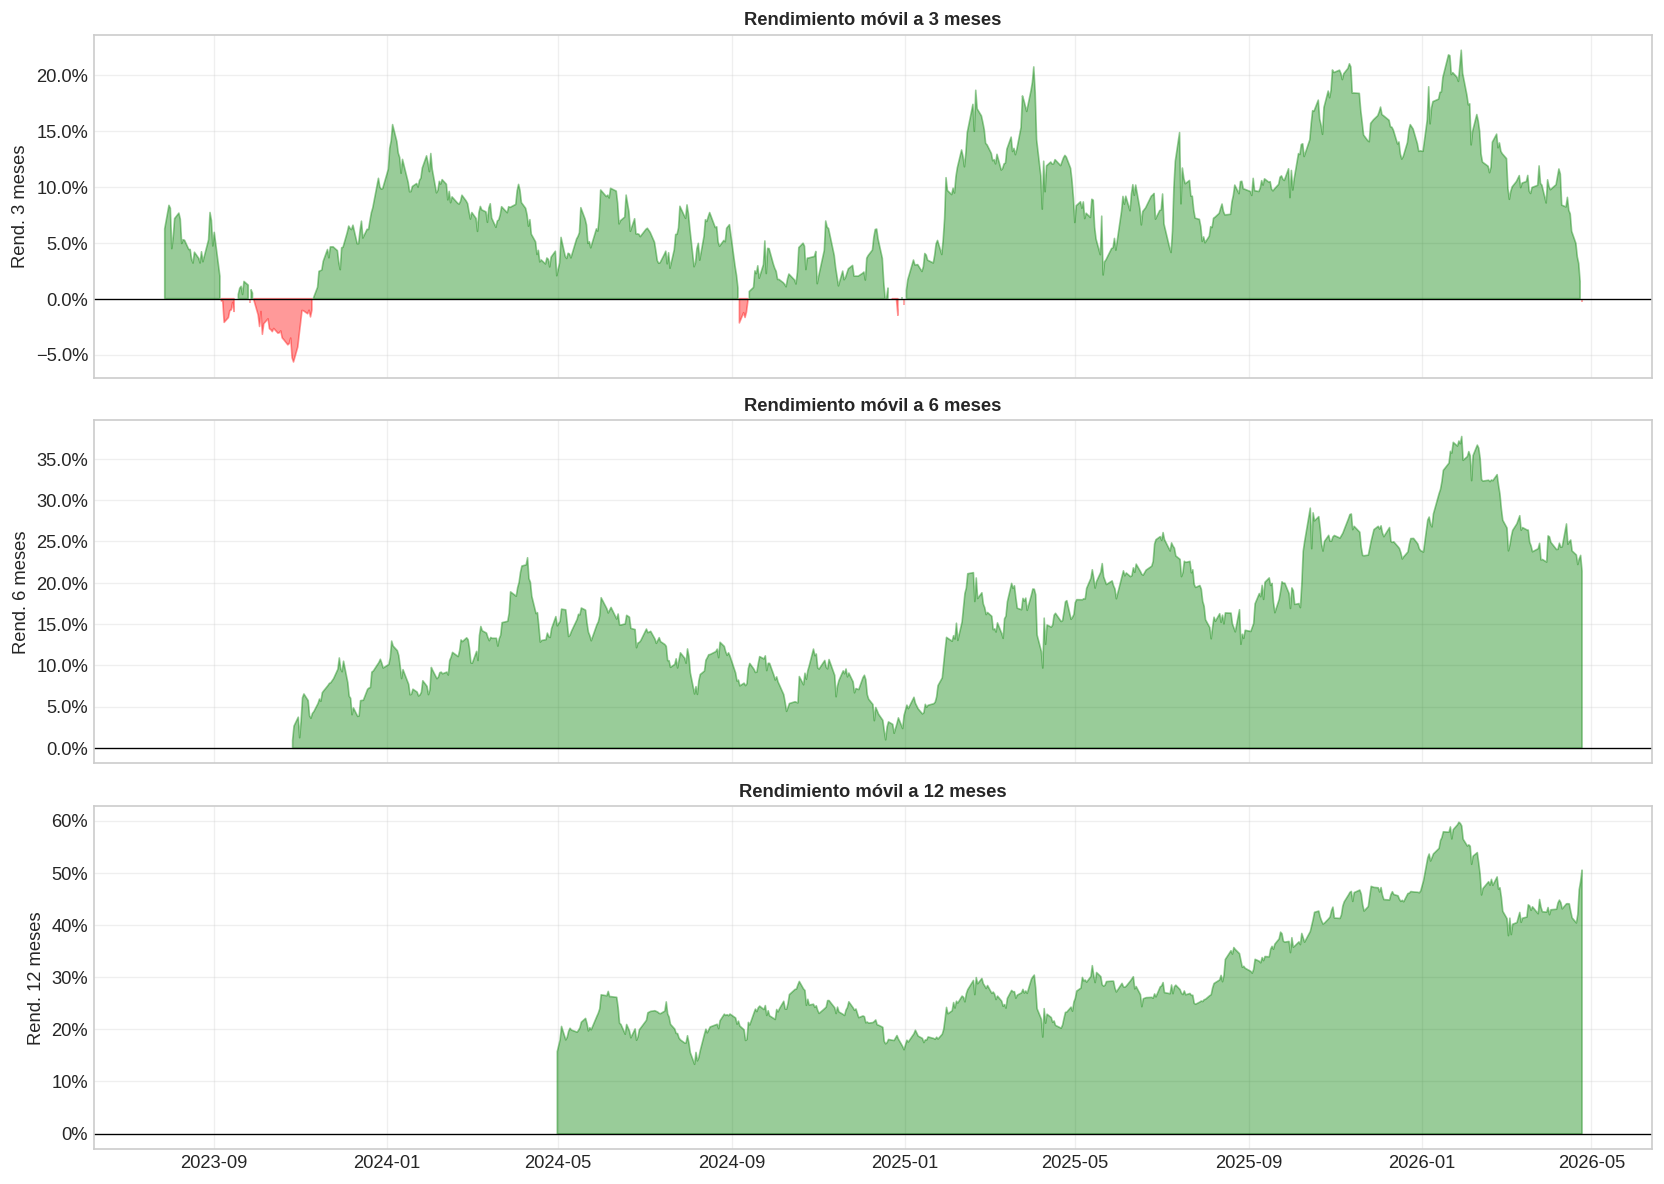

In [17]:
# Rendimientos móviles
ventanas = {'3 meses': 63, '6 meses': 126, '12 meses': 252}

fig, axes = plt.subplots(len(ventanas), 1, figsize=(14, 10), sharex=True)

print(f'{"═" * 55}')
print(f'  ANÁLISIS DE RENDIMIENTOS MÓVILES')
print(f'{"═" * 55}')

for ax, (nombre_v, dias) in zip(axes, ventanas.items()):
    rend_movil = rendimiento_portafolio.rolling(dias).sum()
    rend_movil = rend_movil.dropna()

    # Colorear positivo (verde) y negativo (rojo)
    positivo = rend_movil.copy()
    negativo = rend_movil.copy()
    positivo[positivo < 0] = np.nan
    negativo[negativo >= 0] = np.nan

    ax.fill_between(positivo.index, positivo.values, 0, alpha=0.4, color='green')
    ax.fill_between(negativo.index, negativo.values, 0, alpha=0.4, color='red')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_ylabel(f'Rend. {nombre_v}')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Rendimiento móvil a {nombre_v}', fontsize=11)

    # Estadísticas
    pct_positivo = (rend_movil > 0).sum() / len(rend_movil)
    print(f'\n  Ventana de {nombre_v}:')
    print(f'    Períodos positivos: {pct_positivo:.1%}')
    print(f'    Mejor período:     {rend_movil.max():+.1%}')
    print(f'    Peor período:      {rend_movil.min():+.1%}')
    print(f'    Mediana:           {rend_movil.median():+.1%}')

plt.tight_layout()
plt.savefig('img/09_rendimientos_moviles.png', bbox_inches='tight')
plt.show()

---

## 9. Contribución al riesgo por activo

No todos los activos contribuyen de la misma forma al riesgo total del portafolio. Un activo puede tener un peso pequeño pero contribuir desproporcionadamente al riesgo si es muy volátil o tiene alta correlación con los demás.

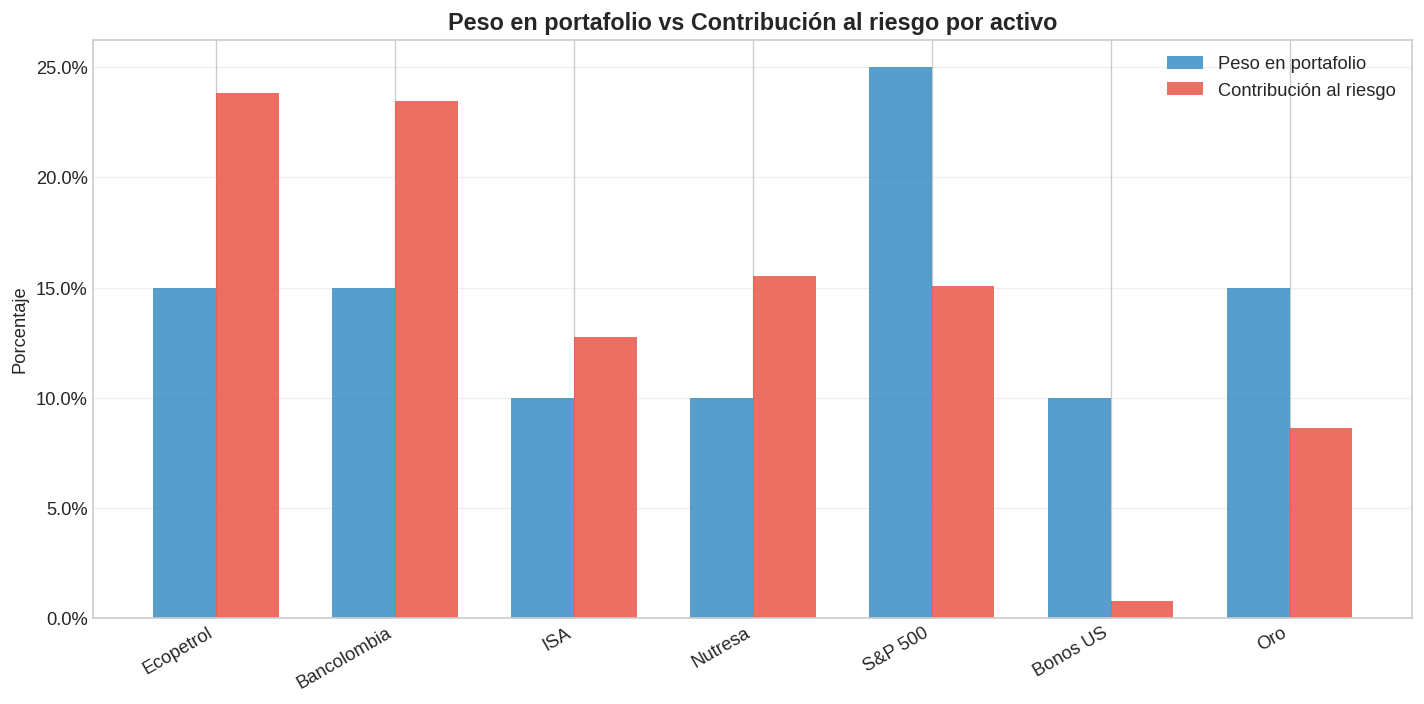


═══════════════════════════════════════════════════════
  CONTRIBUCIÓN AL RIESGO POR ACTIVO
═══════════════════════════════════════════════════════
Activo             Peso  Contrib.Riesgo    Ratio
───────────────────────────────────────────────────────
⚠️Ecopetrol      15.0%          23.8%    1.59x
⚠️Bancolombia    15.0%          23.5%    1.56x
  ISA            10.0%          12.8%    1.28x
⚠️Nutresa        10.0%          15.5%    1.55x
  S&P 500        25.0%          15.1%    0.60x
  Bonos US       10.0%           0.8%    0.08x
  Oro            15.0%           8.6%    0.57x

  📌 Ratio > 1.0x: el activo contribuye más riesgo que su peso.
     Ratio < 1.0x: el activo contribuye menos riesgo (diversifica).


In [18]:
# Contribución marginal al riesgo (Risk Contribution)
def calcular_contribucion_riesgo(pesos, cov_matrix):
    """Calcula la contribución de cada activo al riesgo total del portafolio."""
    vol_port = np.sqrt(np.dot(pesos.T, np.dot(cov_matrix, pesos)))
    contribucion_marginal = np.dot(cov_matrix, pesos) / vol_port
    contribucion_riesgo = pesos * contribucion_marginal
    contribucion_pct = contribucion_riesgo / vol_port
    return contribucion_pct

contrib_riesgo = calcular_contribucion_riesgo(pesos_array, cov_matrix)

# Gráfica de contribución al riesgo vs peso
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(n_activos)
ancho = 0.35

barras1 = ax.bar(x - ancho/2, pesos_array, ancho, label='Peso en portafolio',
                 color=COLORES['sp500'], alpha=0.8)
barras2 = ax.bar(x + ancho/2, contrib_riesgo, ancho, label='Contribución al riesgo',
                 color=COLORES['portafolio'], alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(nombres_activos, rotation=30, ha='right')
ax.set_ylabel('Porcentaje')
ax.set_title('Peso en portafolio vs Contribución al riesgo por activo')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('img/10_contribucion_riesgo.png', bbox_inches='tight')
plt.show()

# Tabla
print(f'\n{"═" * 55}')
print(f'  CONTRIBUCIÓN AL RIESGO POR ACTIVO')
print(f'{"═" * 55}')
print(f'{"Activo":<14} {"Peso":>8} {"Contrib.Riesgo":>15} {"Ratio":>8}')
print(f'{"─" * 55}')
nombres_activos = list(rendimientos.columns)
for i, nombre in enumerate(nombres_activos):
    ratio = contrib_riesgo[i] / pesos_array[i] if pesos_array[i] > 0 else 0
    alerta = '⚠️' if ratio > 1.3 else '  '
    print(f'{alerta}{nombre:<12} {pesos_array[i]:>7.1%} {contrib_riesgo[i]:>14.1%} {ratio:>7.2f}x')

print(f'\n  📌 Ratio > 1.0x: el activo contribuye más riesgo que su peso.')
print(f'     Ratio < 1.0x: el activo contribuye menos riesgo (diversifica).')

---

## 10. Conclusiones y recomendaciones

### Hallazgos principales

In [19]:
# Generar conclusiones automáticas basadas en los datos
mejor_activo = metricas['Sharpe'].idxmax()
peor_activo = metricas['Sharpe'].idxmin()
par_menos_corr = pares_df.iloc[0]
par_mas_corr = pares_df.iloc[-1]
mejor_estrategia = max(resumen_estrategias, key=lambda x: x['Sharpe'])

print(f'{"═" * 70}')
print(f'  RESUMEN EJECUTIVO DEL ANÁLISIS')
print(f'{"═" * 70}')

print(f'''
  1. RENDIMIENTO Y RIESGO
     El portafolio diversificado generó un rendimiento anualizado de {rend_port:+.2%}
     con una volatilidad de {vol_port:.2%}, resultando en un Sharpe de {sharpe_port:.2f}.
     El mejor activo individual por Sharpe fue {mejor_activo} ({metricas.loc[mejor_activo, "Sharpe"]:.2f})
     y el de menor eficiencia fue {peor_activo} ({metricas.loc[peor_activo, "Sharpe"]:.2f}).

  2. DIVERSIFICACIÓN
     La diversificación redujo el riesgo en {reduccion_riesgo:.1%} respecto al promedio
     ponderado de volatilidades individuales.
     El par con menor correlación ({par_menos_corr["Correlación"]:.2f}) fue
     {par_menos_corr["Activo 1"]} - {par_menos_corr["Activo 2"]}, confirmando su
     valor como diversificadores.

  3. OPTIMIZACIÓN
     La simulación Monte Carlo ({N_SIMULACIONES:,} portafolios) identificó que el
     portafolio óptimo por Sharpe ({opt_sharpe["Sharpe"]:.2f}) supera al portafolio
     definido ({sharpe_port:.2f}), sugiriendo margen de mejora en la asignación.
     La mejor estrategia evaluada fue "{mejor_estrategia["Estrategia"]}".

  4. RIESGO
     El VaR 95% indica que en un día normal adverso, la pérdida máxima
     esperada es de {abs(var_95):.2%} (${abs(INVERSION_INICIAL * var_95):,.0f} sobre
     una inversión de ${INVERSION_INICIAL:,.0f}).
     El Maximum Drawdown histórico fue de {max_dd:.1%}, ocurrido
     el {fecha_max_dd.strftime("%Y-%m-%d")}.
''')

print(f'{"═" * 70}')
print(f'  Análisis realizado con Python · Datos: Yahoo Finance · Período: {PERIODO}')
print(f'  Autor: Omar Ortegón · {datetime.now().strftime("%B %Y")}')
print(f'{"═" * 70}')

══════════════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO DEL ANÁLISIS
══════════════════════════════════════════════════════════════════════

  1. RENDIMIENTO Y RIESGO
     El portafolio diversificado generó un rendimiento anualizado de +29.97%
     con una volatilidad de 14.11%, resultando en un Sharpe de 1.77.
     El mejor activo individual por Sharpe fue Bancolombia (1.44)
     y el de menor eficiencia fue Bonos US (-0.25).

  2. DIVERSIFICACIÓN
     La diversificación redujo el riesgo en 46.1% respecto al promedio
     ponderado de volatilidades individuales.
     El par con menor correlación (-0.03) fue
     ISA - Bonos US, confirmando su
     valor como diversificadores.

  3. OPTIMIZACIÓN
     La simulación Monte Carlo (10,000 portafolios) identificó que el
     portafolio óptimo por Sharpe (2.05) supera al portafolio
     definido (1.77), sugiriendo margen de mejora en la asignación.
     La mejor estrategia evaluada fue "Máx Sharpe".

  4. RI

### Limitaciones del análisis

- Los rendimientos pasados no garantizan rendimientos futuros.
- Los datos utilizados son precios en USD, por lo que no incluyen el efecto del tipo de cambio USD/COP para un inversionista colombiano.
- La optimización de Markowitz asume distribución normal de rendimientos y estabilidad de correlaciones, supuestos que se debilitan en períodos de crisis.
- Los costos de transacción, impuestos y comisiones no están incluidos.
- Los tickers de acciones colombianas corresponden a sus ADRs en mercados internacionales, que pueden diferir del comportamiento en la BVC.

### Posibles extensiones

- Incorporar el efecto del tipo de cambio USD/COP en los rendimientos
- Implementar rebalanceo periódico (trimestral, semestral) y evaluar su impacto
- Agregar activos de renta fija colombiana (TES) para representar mejor las opciones locales
- Implementar optimización con restricciones (mínimo/máximo por activo, por clase)
- Backtesting con datos out-of-sample para validar la robustez de la optimización

---

*Este análisis fue desarrollado como parte de un portafolio profesional de analítica financiera. El código completo está disponible en este repositorio para reproducción y extensión.*